# Chapter 1 — Introduction to Phase Unwrapping

A computational companion to Chapter 1 of Ghiglia & Pritt. The figures here are newly generated examples—not copies of the book illustrations. They follow the chapter's four sections: the importance of phase, the need for unwrapping, aspects of one-dimensional unwrapping, and a look ahead to two dimensions.

In [1]:
from pathlib import Path
import sys, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ndtr

ROOT = Path.cwd()
if not (ROOT / 'src' / 'parvaneh').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from parvaneh import SAKURA, SAKURA_DIVERGING, make_synthetic, rmse_aligned, unwrap, wrap_phase
try:
    from skimage.restoration import unwrap_phase as skimage_unwrap
except ImportError:
    skimage_unwrap = None
plt.rcParams.update({'figure.figsize': (11, 4), 'image.cmap': 'viridis'})
TWO_PI = 2*np.pi

## 1.1 The importance of phase

### Fourier magnitude versus Fourier phase

Chapter 1 emphasizes that Fourier phase carries much of an image's structural location information. For $F(u,v)=|F|e^{i\theta}$, magnitude describes how much of each spatial frequency exists, while phase says how those components align. These synthetic shapes avoid borrowing the book's source images.

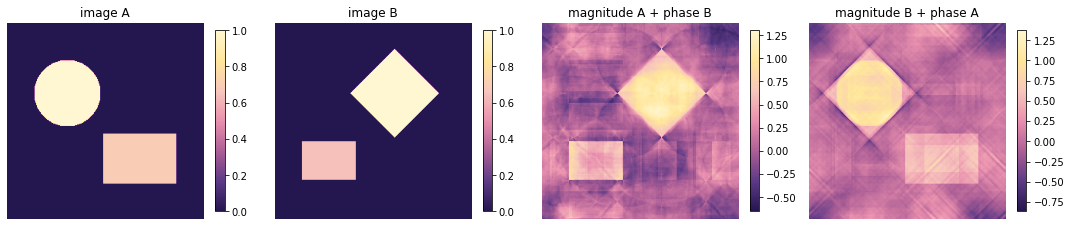

In [2]:
n=256; yy,xx=np.mgrid[:n,:n]
image_a=np.zeros((n,n)); image_a[((xx-78)**2+(yy-92)**2)<43**2]=1; image_a[145:210,125:220]=.7
image_b=np.zeros((n,n)); image_b[(np.abs(xx-155)+np.abs(yy-92))<58]=1; image_b[155:205,35:105]=.65
Fa,Fb=np.fft.fft2(image_a),np.fft.fft2(image_b)
hybrid_a_mag=np.fft.ifft2(np.abs(Fa)*np.exp(1j*np.angle(Fb))).real
hybrid_a_phase=np.fft.ifft2(np.abs(Fb)*np.exp(1j*np.angle(Fa))).real
fig,ax=plt.subplots(1,4,figsize=(15,4))
for a,im,title in zip(ax,[image_a,image_b,hybrid_a_mag,hybrid_a_phase],
        ['image A','image B','magnitude A + phase B','magnitude B + phase A']):
    m=a.imshow(im,cmap=SAKURA);a.set_title(title);a.axis('off');fig.colorbar(m,ax=a,shrink=.68)
fig.tight_layout();plt.show();plt.close(fig)

### Translation changes phase, not magnitude

The Fourier shift theorem is $f(x-x_0,y-y_0)\leftrightarrow F(u,v)e^{-i2\pi(ux_0+vy_0)}$. A spatial translation adds a linear phase ramp while leaving $|F|$ unchanged.

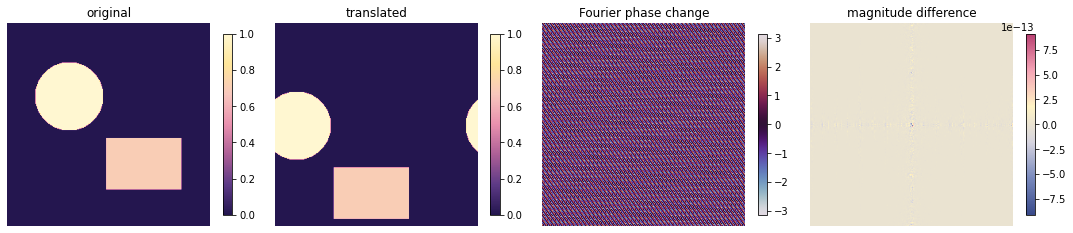

maximum Fourier-magnitude difference: 9.094947017729282e-13


In [3]:
shifted=np.roll(np.roll(image_a,37,axis=0),-51,axis=1);Fs=np.fft.fft2(shifted)
phase_change=wrap_phase(np.angle(Fs)-np.angle(Fa));magnitude_error=np.abs(Fs)-np.abs(Fa)
fig,ax=plt.subplots(1,4,figsize=(15,4))
items=[(image_a,'original',SAKURA,{}),(shifted,'translated',SAKURA,{}),
       (np.fft.fftshift(phase_change),'Fourier phase change','twilight',{'vmin':-np.pi,'vmax':np.pi}),
       (np.fft.fftshift(magnitude_error),'magnitude difference',SAKURA_DIVERGING,{})]
for a,(im,title,cmap,kw) in zip(ax,items):m=a.imshow(im,cmap=cmap,**kw);a.set_title(title);a.axis('off');fig.colorbar(m,ax=a,shrink=.68)
fig.tight_layout();plt.show();plt.close(fig)
print('maximum Fourier-magnitude difference:',np.max(np.abs(magnitude_error)))

### Complex magnitude and phase

A complex measurement $z=Ae^{i\phi}$ has magnitude $A$ and phase $\phi$. Magnitude says how strong the signal is; phase records displacement, delay, optical path length, or surface height. The next example constructs a synthetic complex field and separates those two kinds of information.

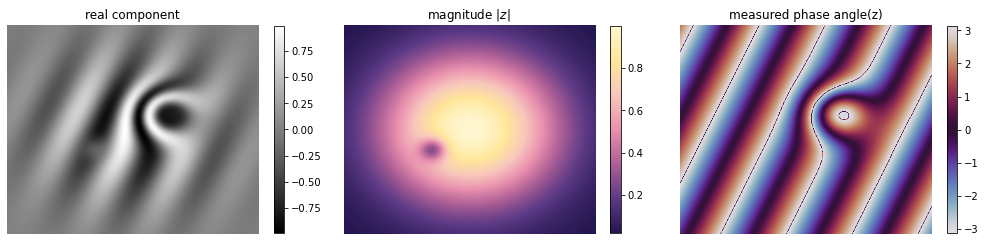

In [4]:
y, x = np.mgrid[-1:1:300j, -1:1:360j]
amplitude = np.exp(-2*(x*x+y*y)) * (1 - .65*np.exp(-80*((x+.3)**2+(y-.2)**2)))
true_phase = 12*x + 5*y + 7*np.exp(-18*((x-.25)**2+(y+.15)**2))
field = amplitude * np.exp(1j*true_phase)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, image, title, cmap in zip(ax, [np.real(field), np.abs(field), np.angle(field)],
        ['real component', 'magnitude $|z|$', 'measured phase angle(z)'],
        ['gray', SAKURA, 'twilight']):
    m=a.imshow(image,cmap=cmap); a.set_title(title); a.axis('off'); fig.colorbar(m,ax=a,shrink=.78)
fig.tight_layout(); plt.show(); plt.close(fig)

## 1.2 The need for phase unwrapping

### Wrap-operator identities and non-uniqueness

Useful identities are $W(\phi+2\pi k)=W(\phi)$ and $W(a+b)=W(W(a)+W(b))$. The first proves that wrapped samples alone cannot determine the integer field: infinitely many surfaces have identical observations. Smoothness, quality, masks, or other physical priors select among them.

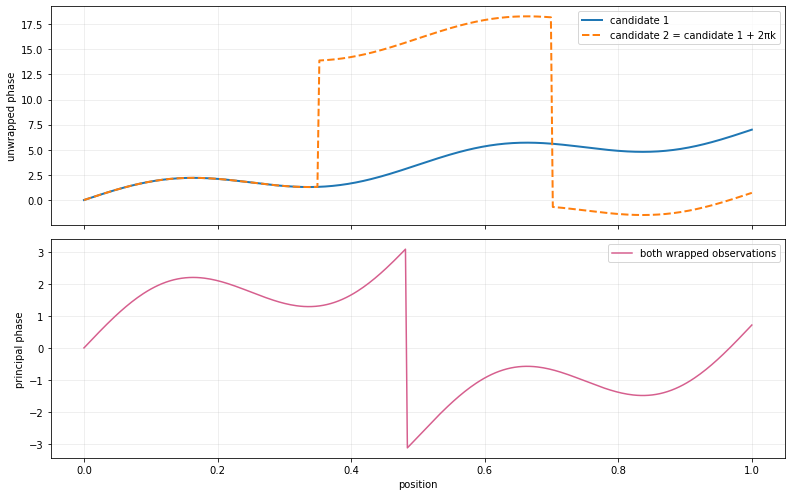

wrapped observations identical: True


In [5]:
q=np.linspace(0,1,350);base=7*q+1.2*np.sin(4*np.pi*q);integer_field=np.where(q<.35,0,np.where(q<.7,2,-1))
alternative=base+TWO_PI*integer_field
fig,ax=plt.subplots(2,1,figsize=(11,7),sharex=True)
ax[0].plot(q,base,lw=2,label='candidate 1');ax[0].plot(q,alternative,'--',lw=2,label='candidate 2 = candidate 1 + 2πk');ax[0].legend();ax[0].set_ylabel('unwrapped phase');ax[0].grid(alpha=.25)
ax[1].plot(q,wrap_phase(base),color='#d65f8e',label='both wrapped observations');ax[1].set(xlabel='position',ylabel='principal phase');ax[1].legend();ax[1].grid(alpha=.25)
fig.tight_layout();plt.show();plt.close(fig)
print('wrapped observations identical:',np.allclose(wrap_phase(base),wrap_phase(alternative)))

### Quantized phase measurements

The supplied book phase rasters store one cycle in 256 byte levels. Quantization spacing is $2\pi/256\approx0.02454$ rad. Quantization alone is small, but it can change a wrapped difference lying extremely close to $\pm\pi$.

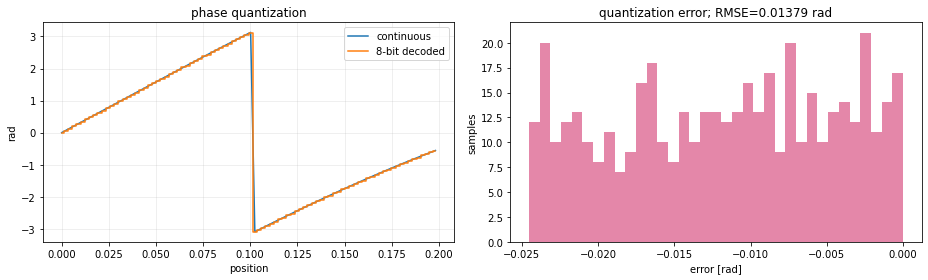

In [6]:
tq=np.linspace(0,1,450);quant_truth=4*np.pi*tq+3*np.sin(2*np.pi*tq)+10*tq*tq
continuous=wrap_phase(quant_truth);codes=np.floor((continuous+np.pi)*256/TWO_PI).astype(np.uint8)
decoded=codes.astype(float)*TWO_PI/256-np.pi;quant_error=wrap_phase(decoded-continuous)
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].plot(tq[:90],continuous[:90],label='continuous');ax[0].step(tq[:90],decoded[:90],where='mid',label='8-bit decoded');ax[0].set(title='phase quantization',xlabel='position',ylabel='rad');ax[0].legend();ax[0].grid(alpha=.25)
ax[1].hist(quant_error,bins=35,color='#e487a9');ax[1].set(title=f'quantization error; RMSE={np.sqrt(np.mean(quant_error**2)):.5f} rad',xlabel='error [rad]',ylabel='samples')
fig.tight_layout();plt.show();plt.close(fig)

### Interference turns phase into visible fringes

Interferometers mix a reference wave and a measurement wave. Their intensity contains a cosine of the phase difference, producing fringes. Each full fringe represents one $2\pi$ phase cycle.

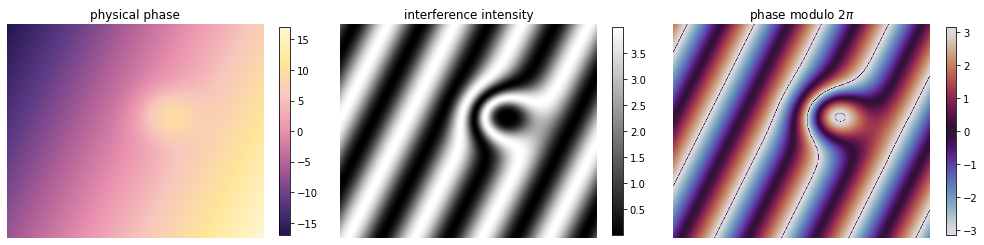

In [7]:
reference = np.exp(1j * 18*x)
measurement = np.exp(1j * (18*x + true_phase))
interferogram = np.abs(reference + measurement)**2
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, image, title, cmap in zip(ax, [true_phase, interferogram, wrap_phase(true_phase)],
        ['physical phase', 'interference intensity', 'phase modulo $2\pi$'],
        [SAKURA, 'gray', 'twilight']):
    m=a.imshow(image,cmap=cmap); a.set_title(title); a.axis('off'); fig.colorbar(m,ax=a,shrink=.78)
fig.tight_layout(); plt.show(); plt.close(fig)

### Recovering the integer wrap count

The measured principal phase is $\psi=W(\phi)\in[-\pi,\pi)$, where $W(a)=((a+\pi)\bmod 2\pi)-\pi$. Thus $\phi=\psi+2\pi k$ for an unknown integer wrap count $k$. Unwrapping estimates that integer field; the absolute additive multiple of $2\pi$ remains unknowable without a reference.

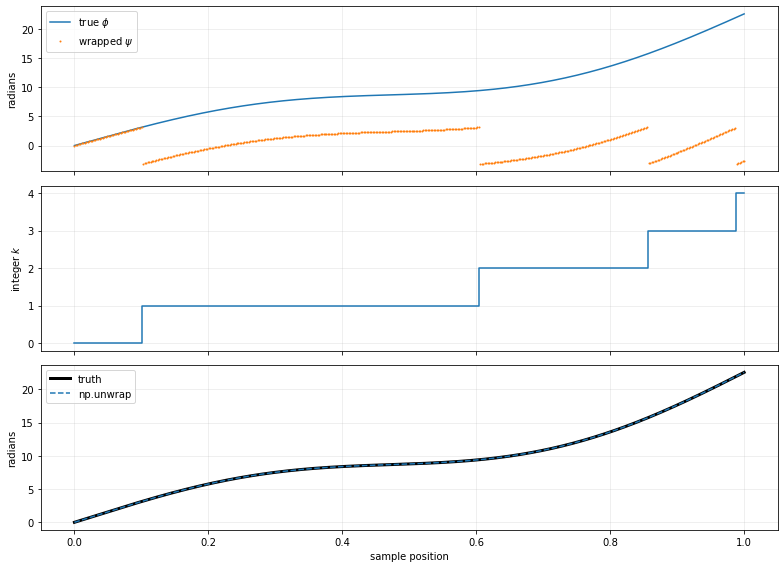

In [8]:
t = np.linspace(0, 1, 450)
phi = 4*np.pi*t + 3*np.sin(2*np.pi*t) + 10*t*t
psi = wrap_phase(phi)
k = np.rint((phi-psi)/TWO_PI).astype(int)
recovered = np.unwrap(psi)
fig, ax = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
ax[0].plot(t,phi,label='true $\phi$'); ax[0].plot(t,psi,'.',ms=2,label='wrapped $\psi$')
ax[0].legend(); ax[0].set_ylabel('radians'); ax[0].grid(alpha=.25)
ax[1].step(t,k,where='mid'); ax[1].set_ylabel('integer $k$'); ax[1].grid(alpha=.25)
ax[2].plot(t,phi,'k',lw=3,label='truth'); ax[2].plot(t,recovered,'--',label='np.unwrap')
ax[2].set(xlabel='sample position',ylabel='radians'); ax[2].legend(); ax[2].grid(alpha=.25)
fig.tight_layout(); plt.show(); plt.close(fig)

## 1.3 One-dimensional phase unwrapping

Itoh's sequential rule integrates wrapped differences: $\hat\phi[n]=\hat\phi[n-1]+W(\psi[n]-\psi[n-1])$. Since $\psi[n]=W(\phi[n])$, the wrap identity gives $W(\psi[n]-\psi[n-1])=W(\Delta\phi[n])$. If $|\Delta\phi[n]|<\pi$, then $W(\Delta\phi[n])=\Delta\phi[n]$ and cumulative summation recovers the phase up to its initial constant. This is a sampling condition, not merely a programming detail.

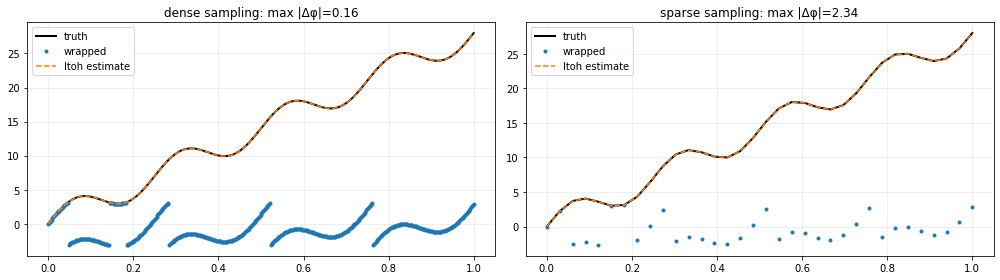

In [9]:
def itoh_1d(wrapped):
    out = np.empty_like(wrapped, dtype=float)
    out[0] = wrapped[0]
    out[1:] = out[0] + np.cumsum(wrap_phase(np.diff(wrapped)))
    return out

dense_x = np.linspace(0,1,500); sparse_x = np.linspace(0,1,34)
f = lambda q: 28*q + 2*np.sin(8*np.pi*q)
fig, ax = plt.subplots(1,2,figsize=(14,4))
for a, q, label in [(ax[0],dense_x,'dense sampling'),(ax[1],sparse_x,'sparse sampling')]:
    truth=f(q); wrapped=wrap_phase(truth); estimate=itoh_1d(wrapped)
    a.plot(q,truth,'k',lw=2,label='truth'); a.plot(q,wrapped,'.',label='wrapped')
    a.plot(q,estimate,'--',label='Itoh estimate')
    worst=np.max(np.abs(np.diff(truth))); a.set_title(f'{label}: max |Δφ|={worst:.2f}')
    a.grid(alpha=.25); a.legend()
fig.tight_layout(); plt.show(); plt.close(fig)

### Aliasing: two sampled phases, one observation

The local condition is fundamental. Adding $2\pi n$ at sample index $n$ changes every true increment by $2\pi$ but leaves every wrapped sample unchanged. No algorithm using only those samples can decide which slope was present.

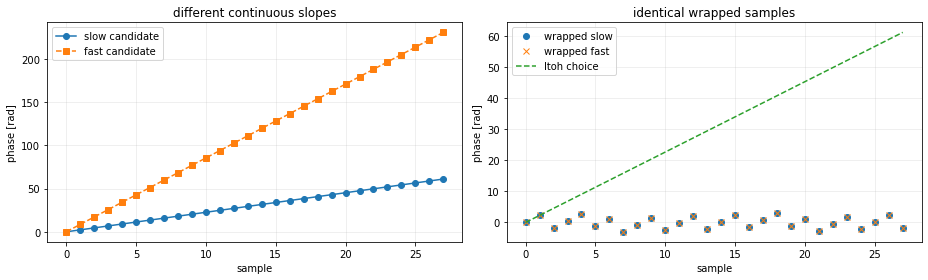

observations exactly equal: True


In [10]:
index=np.arange(28);slow=.72*np.pi*index;fast=slow+TWO_PI*index;observation=wrap_phase(slow)
estimate=itoh_1d(observation)
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].plot(index,slow,'o-',label='slow candidate');ax[0].plot(index,fast,'s--',label='fast candidate');ax[0].set(title='different continuous slopes',xlabel='sample',ylabel='phase [rad]');ax[0].legend();ax[0].grid(alpha=.25)
ax[1].plot(index,wrap_phase(slow),'o',label='wrapped slow');ax[1].plot(index,wrap_phase(fast),'x',label='wrapped fast');ax[1].plot(index,estimate,'--',label='Itoh choice');ax[1].set(title='identical wrapped samples',xlabel='sample',ylabel='phase [rad]');ax[1].legend();ax[1].grid(alpha=.25)
fig.tight_layout();plt.show();plt.close(fig)
print('observations exactly equal:',np.allclose(wrap_phase(slow),wrap_phase(fast)))

### Probability of a noise-induced cycle slip

If independent sample noise has standard deviation $\sigma$, its difference has standard deviation $\sqrt{2}\sigma$. For a true increment $d$, a local slip occurs when $|d+\eta|>\pi$. Thus

$$P_{\rm slip}=\Phi\!\left(\frac{-\pi-d}{\sqrt2\sigma}\right)+1-\Phi\!\left(\frac{\pi-d}{\sqrt2\sigma}\right).$$

The simulation markers below verify the formula and show why slopes close to $\pi$ are fragile even under moderate noise.

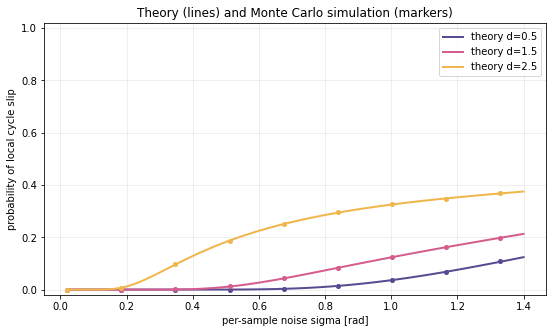

In [11]:
sigma_grid=np.linspace(.02,1.4,60);increments=[.5,1.5,2.5];fig,ax=plt.subplots(figsize=(9,5));rng_prob=np.random.default_rng(91)
for color,d in zip(['#5a4a91','#d45d8d','#efb64c'],increments):
    sd=np.sqrt(2)*sigma_grid;theory=ndtr((-np.pi-d)/sd)+1-ndtr((np.pi-d)/sd)
    check_sigma=sigma_grid[::7];sim=[]
    for sigma in check_sigma:
        eta=rng_prob.normal(0,np.sqrt(2)*sigma,40000);sim.append(np.mean(np.abs(d+eta)>np.pi))
    ax.plot(sigma_grid,theory,color=color,lw=2,label=f'theory d={d:.1f}');ax.plot(check_sigma,sim,'o',color=color,ms=4)
ax.set(xlabel='per-sample noise sigma [rad]',ylabel='probability of local cycle slip',title='Theory (lines) and Monte Carlo simulation (markers)',ylim=(-.02,1.02));ax.grid(alpha=.25);ax.legend()
plt.show();plt.close(fig)

### Failure modes: undersampling, noise, and true discontinuities

A wrapped measurement cannot distinguish a genuine phase jump from a removed $2\pi$ cycle. Once a local mistake occurs, sequential integration carries that integer-cycle error into all later samples.

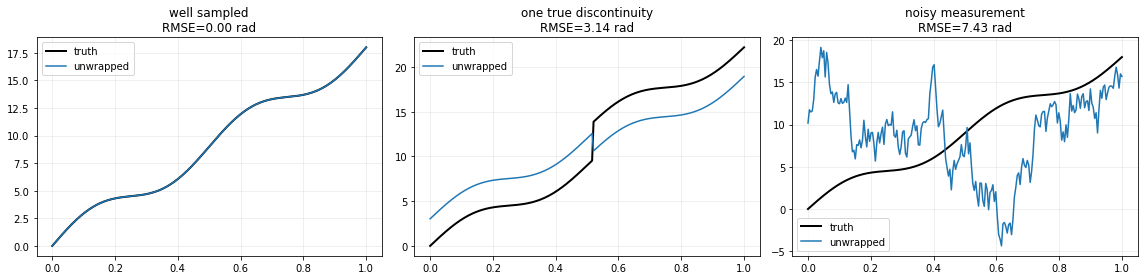

In [12]:
rng=np.random.default_rng(12); q=np.linspace(0,1,220)
cases = {
 'well sampled': 18*q + 1.2*np.sin(4*np.pi*q),
 'one true discontinuity': 18*q + 1.2*np.sin(4*np.pi*q) + (q>.52)*4.2,
 'noisy measurement': 18*q + 1.2*np.sin(4*np.pi*q),
}
fig,ax=plt.subplots(1,3,figsize=(16,4))
for a,(title,truth) in zip(ax,cases.items()):
    noise = rng.normal(0,1.35,q.size) if title=='noisy measurement' else 0
    observed=wrap_phase(truth+noise); estimate=itoh_1d(observed)
    estimate += np.mean(truth-estimate)
    a.plot(q,truth,'k',lw=2,label='truth'); a.plot(q,estimate,label='unwrapped')
    a.set_title(f'{title}\nRMSE={np.sqrt(np.mean((estimate-truth)**2)):.2f} rad')
    a.grid(alpha=.25); a.legend()
fig.tight_layout(); plt.show(); plt.close(fig)

### Parameter sweep: where the simple rule breaks

This experiment varies phase slope and noise. Dark regions are easy; bright bands indicate integer-cycle failures. It makes the $|\Delta\phi|<\pi$ boundary visible.

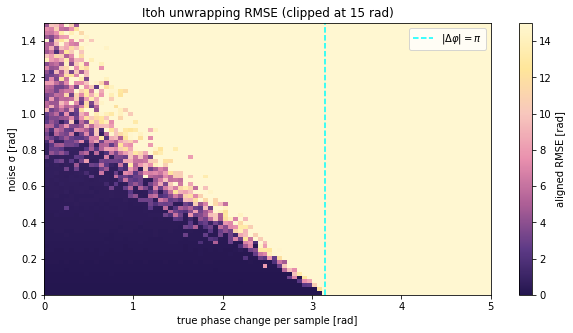

In [13]:
slopes=np.linspace(0,5,90); noises=np.linspace(0,1.5,70); n=180
errors=np.empty((len(noises),len(slopes)))
for iy,sigma in enumerate(noises):
    for ix,slope in enumerate(slopes):
        truth=slope*np.arange(n); obs=wrap_phase(truth+rng.normal(0,sigma,n))
        est=itoh_1d(obs); est+=np.mean(truth-est)
        errors[iy,ix]=np.sqrt(np.mean((est-truth)**2))
fig,ax=plt.subplots(figsize=(10,5))
m=ax.imshow(np.clip(errors,0,15),origin='lower',aspect='auto',
 extent=[slopes[0],slopes[-1],noises[0],noises[-1]],cmap=SAKURA)
ax.axvline(np.pi,color='cyan',ls='--',label='$|Δφ|=π$'); ax.legend()
ax.set(xlabel='true phase change per sample [rad]',ylabel='noise σ [rad]',title='Itoh unwrapping RMSE (clipped at 15 rad)')
fig.colorbar(m,ax=ax,label='aligned RMSE [rad]'); plt.show(); plt.close(fig)

## 1.4 Brief look ahead: two dimensions

In 2-D there are many integration paths. With consistent, well-sampled data they agree. Noise or phase singularities can make path results disagree, motivating residues, branch cuts, quality-guided paths, and global least-squares methods in later chapters. The row-then-column demonstration below is intentionally simple.

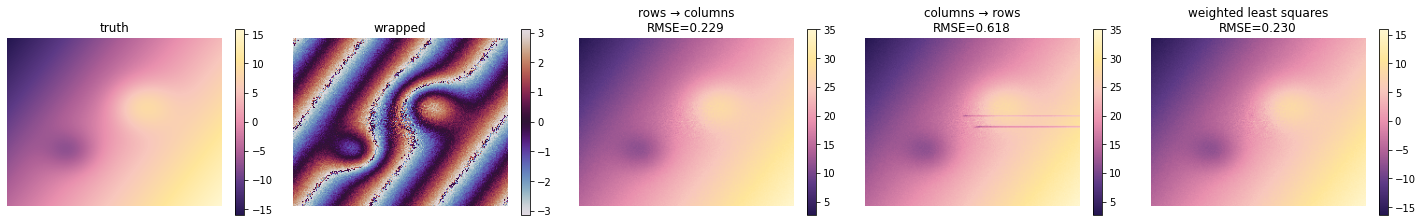

In [14]:
truth,wrapped,weight=make_synthetic((180,230),noise=.18,seed=9)
row_then_col=np.unwrap(np.unwrap(wrapped,axis=1),axis=0)
col_then_row=np.unwrap(np.unwrap(wrapped,axis=0),axis=1)
least_squares=unwrap(wrapped,weight,backend='numba')
methods=[('truth',truth),('wrapped',wrapped),('rows → columns',row_then_col),
         ('columns → rows',col_then_row),('weighted least squares',least_squares)]
fig,ax=plt.subplots(1,5,figsize=(20,4))
for a,(title,image) in zip(ax,methods):
    m=a.imshow(image,cmap='twilight' if title=='wrapped' else SAKURA); a.axis('off')
    metric='' if title in ('truth','wrapped') else f'\nRMSE={rmse_aligned(image,truth):.3f}'
    a.set_title(title+metric); fig.colorbar(m,ax=a,shrink=.7)
fig.tight_layout(); plt.show(); plt.close(fig)

## Why NumPy, BLAS, Numba, and Cython had similar speed

Only the weighted-Laplacian stencil was replaced by Numba/Cython. Each PCG iteration still performs SciPy DCTs, inverse DCTs, norms, allocations, and memory transfers. Those shared operations dominate at these image sizes. BLAS accelerates dot products, but dot products are also a small fraction of total time. A GPU helps only when the entire iteration—including transforms and data—stays on the GPU, and transfer/launch overhead is amortized by large images or batches.

Algorithm choice can matter more than kernel choice. `skimage.restoration.unwrap_phase` is a compiled reliability-guided method and solves a different objective; compare both runtime and accuracy rather than runtime alone.

In [15]:
sizes=[128,256,512,1024]; rows=[]
for size in sizes:
    truth,wrapped,weight=make_synthetic((size,size),noise=.05,seed=2)
    for name,fn in [('least-squares',lambda: unwrap(wrapped,weight,backend='numba')),
                    ('scikit-image',lambda: skimage_unwrap(wrapped) if skimage_unwrap else None)]:
        if name=='scikit-image' and skimage_unwrap is None: continue
        fn()  # warm-up
        start=time.perf_counter(); result=fn(); elapsed=time.perf_counter()-start
        rows.append((size,name,elapsed,rmse_aligned(result,truth)))
for size,name,elapsed,error in rows:
    print(f'{size:4d}²  {name:15s} {elapsed:8.4f}s  aligned RMSE={error:.5f}')

 128²  least-squares     0.0431s  aligned RMSE=0.06377
 128²  scikit-image      0.0075s  aligned RMSE=0.06377
 256²  least-squares     0.1522s  aligned RMSE=0.06329
 256²  scikit-image      0.0383s  aligned RMSE=0.06329
 512²  least-squares     1.2987s  aligned RMSE=0.06365
 512²  scikit-image      0.2001s  aligned RMSE=0.06365
1024²  least-squares     2.6156s  aligned RMSE=0.06388
1024²  scikit-image      0.7721s  aligned RMSE=0.06388


## Why GPU acceleration is not used here

The timings above come from a CPU with no NVIDIA CUDA device, so CuPy is
correctly reported unavailable (`available_backends()["cupy"] is False`). An
integrated GPU cannot be made CUDA-capable by installing a driver; targeting it
needs a separately implemented OpenCL or SYCL backend, and for arrays of this
size the transfer and launch overhead is unlikely to be repaid.

The speedups that remain available on a CPU are: replace the whole algorithm
rather than one kernel, avoid unnecessary allocations, use multi-worker FFT/DCT
transforms, batch independent problems, relax an unnecessarily strict
convergence tolerance, and choose an algorithm whose error behaviour suits the
data.


## Chapter 1 takeaways

1. Fourier phase carries structural alignment; translation changes phase while preserving magnitude.
2. Measurement returns phase modulo $2\pi$, so infinitely many unwrapped candidates share one observation.
3. One-dimensional sequential unwrapping is exact when every true sample increment lies inside $(-\pi,\pi)$.
4. Sampling ambiguity cannot be repaired by a faster or more sophisticated algorithm without additional information.
5. Noise gives a calculable probability of local cycle slips, especially when slopes approach $\pi$.
6. Eight-bit phase quantization is usually small but matters near the wrapping threshold.
7. Two dimensions add path choices; later chapters develop methods for handling inconsistency.
8. Faster kernels do not automatically make the complete solver faster—profile the whole algorithm.